<a href="https://colab.research.google.com/github/beingdeveloper21/miiiiini/blob/main/MINI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# XGBoost
from xgboost import XGBRegressor

In [24]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/craigslist_vehicles.csv'
df = pd.read_csv(file_path)

# Display first rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,id,url,region,region_url,price,year,manufacturer,model,condition,...,type,paint_color,image_url,description,county,state,lat,long,posting_date,removal_date
0,362773,7307679724,https://abilene.craigslist.org/ctd/d/abilene-2...,abilene,https://abilene.craigslist.org,4500,2002.0,bmw,x5,NaN,...,NaN,NaN,https://images.craigslist.org/00m0m_iba78h8ty9...,"$4,500 Cash 2002 BMW X5 8 cylinder 4.4L moto...",NaN,tx,32.401556,-99.884713,2021-04-16 00:00:00+00:00,2021-05-02 00:00:00+00:00
1,362712,7311833696,https://abilene.craigslist.org/ctd/d/abilene-2...,abilene,https://abilene.craigslist.org,4500,2002.0,bmw,x5,NaN,...,NaN,NaN,https://images.craigslist.org/00m0m_iba78h8ty9...,"$4,500 Cash 2002 BMW X5 8 cylinder 4.4L moto...",NaN,tx,32.401556,-99.884713,2021-04-24 00:00:00+00:00,2021-04-28 00:00:00+00:00
2,362722,7311441996,https://abilene.craigslist.org/ctd/d/abilene-2...,abilene,https://abilene.craigslist.org,4900,2006.0,toyota,camry,excellent,...,sedan,silver,https://images.craigslist.org/00808_5FkOw2aGjA...,2006 TOYOTA CAMRY LE Sedan Ready To Upgrade ...,NaN,tx,32.453848,-99.787900,2021-04-23 00:00:00+00:00,2021-05-25 00:00:00+00:00
3,362771,7307680715,https://abilene.craigslist.org/ctd/d/abilene-2...,abilene,https://abilene.craigslist.org,6500,2008.0,ford,expedition,NaN,...,NaN,NaN,https://images.craigslist.org/00M0M_i9CoFvVq8o...,$6500.00 2008 Ford Expedition 8 cylinder 5.4L...,NaN,tx,32.401556,-99.884713,2021-04-16 00:00:00+00:00,2021-04-26 00:00:00+00:00
4,362710,7311834578,https://abilene.craigslist.org/ctd/d/abilene-2...,abilene,https://abilene.craigslist.org,6500,2008.0,ford,expedition,NaN,...,NaN,NaN,https://images.craigslist.org/00M0M_i9CoFvVq8o...,$6500.00 2008 Ford Expedition 8 cylinder 5.4L...,NaN,tx,32.401556,-99.884713,2021-04-24 00:00:00+00:00,2021-05-12 00:00:00+00:00


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (426880, 28)

Column Names:
Index(['Unnamed: 0', 'id', 'url', 'region', 'region_url', 'price', 'year',
       'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer',
       'title_status', 'transmission', 'VIN', 'drive', 'size', 'type',
       'paint_color', 'image_url', 'description', 'county', 'state', 'lat',
       'long', 'posting_date', 'removal_date'],
      dtype='object')

Data Types:
Unnamed: 0        int64
id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county          float64
state            objec

In [27]:
columns_to_drop = [
    'id','VIN','region','state','url','region_url','image_url',
    'description','county','lat','long','posting_date','removal_date'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

df.head()

,Unnamed: 0,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color
0,362773,4500,2002.0,bmw,x5,NaN,NaN,gas,184000.0,clean,automatic,NaN,NaN,NaN,NaN
1,362712,4500,2002.0,bmw,x5,NaN,NaN,gas,184000.0,clean,automatic,NaN,NaN,NaN,NaN
2,362722,4900,2006.0,toyota,camry,excellent,4 cylinders,gas,184930.0,clean,automatic,fwd,NaN,sedan,silver
3,362771,6500,2008.0,ford,expedition,NaN,NaN,gas,206000.0,clean,automatic,NaN,NaN,NaN,NaN
4,362710,6500,2008.0,ford,expedition,NaN,NaN,gas,206000.0,clean,automatic,NaN,NaN,NaN,NaN


In [28]:
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numeric missing values with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [29]:
# Remove price = 0
df = df[df['price'] > 0]

# Remove extreme price outliers
price_limit = df['price'].quantile(0.999)
df = df[df['price'] < price_limit]

# Remove extreme odometer values
odo_limit = df['odometer'].quantile(0.999)
df = df[df['odometer'] < odo_limit]

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (393156, 15)


In [30]:
# Reduce dataset size for faster training
df = df.sample(n=40000, random_state=42)

print("Sampled Dataset Shape:", df.shape)

Sampled Dataset Shape: (40000, 15)


In [31]:
# Log transform price to reduce skewness and improve model performance
df['price'] = np.log1p(df['price'])

print("Log transformation applied to price")

Log transformation applied to price


In [32]:
current_year = 2024
df['vehicle_age'] = current_year - df['year']

In [33]:
condition_map = {
    'new':5,
    'like new':5,
    'excellent':4,
    'good':3,
    'fair':2,
    'salvage':1
}

df['condition_score'] = df['condition'].map(condition_map).fillna(3)

title_map = {
    'clean':1,
    'rebuilt':0,
    'salvage':0,
    'lien':0,
    'missing':0,
    'parts only':0
}

df['title_score'] = df['title_status'].map(title_map).fillna(0)

# Normalize odometer
df['odo_score'] = 1 - (df['odometer'] - df['odometer'].min()) / (df['odometer'].max() - df['odometer'].min())

# Normalize vehicle age
df['age_score'] = 1 - (df['vehicle_age'] - df['vehicle_age'].min()) / (df['vehicle_age'].max() - df['vehicle_age'].min())

# Final maintenance score
df['maintenance_score'] = (
    0.4 * df['condition_score'] +
    0.3 * df['title_score'] +
    0.2 * df['odo_score'] +
    0.1 * df['age_score']
)

In [34]:
# Additional useful features

# Mileage per year (very powerful feature)
df['mileage_per_year'] = df['odometer'] / (df['vehicle_age'] + 1)

# Car value depreciation factor
df['depreciation_factor'] = df['vehicle_age'] * df['odometer']

# Normalize price by age
df['price_per_age'] = df['price'] / (df['vehicle_age'] + 1)

print("New engineered features added")

New engineered features added


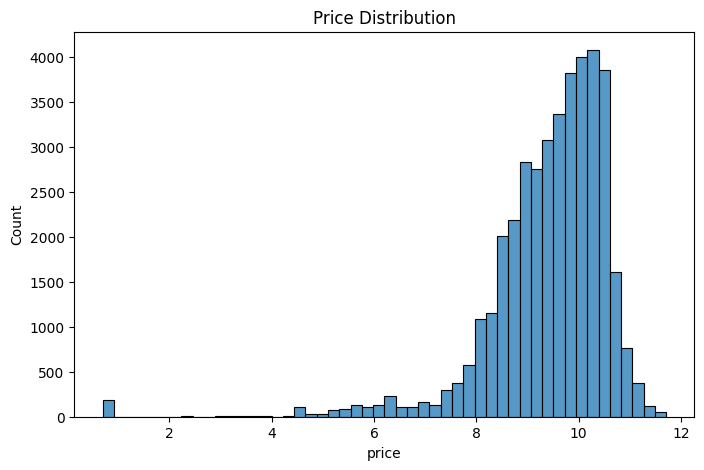

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

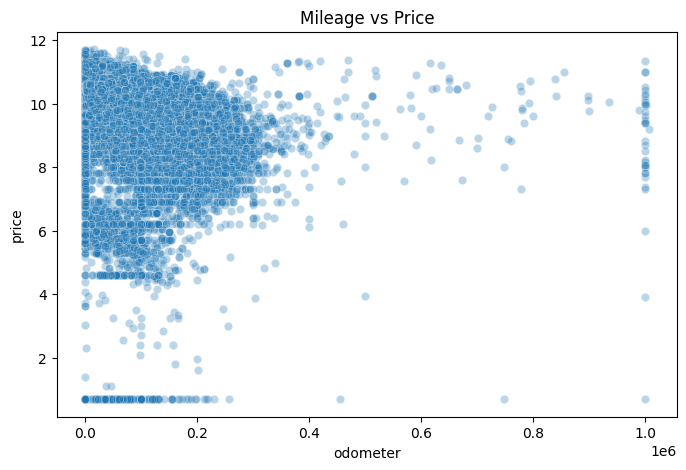

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['odometer'], y=df['price'], alpha=0.3)
plt.title("Mileage vs Price")
plt.show()

In [37]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.shape

(40000, 8214)

In [38]:
# Remove extremely low variance columns (noise reduction)
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.001)
df_encoded = pd.DataFrame(
    selector.fit_transform(df_encoded),
    columns=df_encoded.columns[selector.get_support()]
)

print("Shape after removing low variance features:", df_encoded.shape)

Shape after removing low variance features: (40000, 252)


In [39]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [40]:
important_features = ['year','odometer','vehicle_age','maintenance_score']

X_train_small = X_train[important_features]
X_test_small = X_test[important_features]

In [41]:
scaler = StandardScaler()

X_train_small = scaler.fit_transform(X_train_small)
X_test_small = scaler.transform(X_test_small)

In [42]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train_small)
X_test_poly = poly.transform(X_test_small)

In [43]:
cubic_model = LinearRegression()
cubic_model.fit(X_train_poly, y_train)

LinearRegression()

In [44]:
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=-1, num_parallel_tree=None, ...)

In [45]:
cubic_pred = cubic_model.predict(X_test_poly)
xgb_pred = xgb_model.predict(X_test)

In [46]:
# Find best ensemble weight automatically
best_r2 = -1
best_weight = 0

for w in np.arange(0.1, 0.9, 0.1):
    temp_pred = w * cubic_pred + (1 - w) * xgb_pred
    temp_r2 = r2_score(y_test, temp_pred)

    if temp_r2 > best_r2:
        best_r2 = temp_r2
        best_weight = w

ensemble_pred = best_weight * cubic_pred + (1 - best_weight) * xgb_pred

print("Best ensemble weight:", best_weight)

Best ensemble weight: 0.1


In [47]:
# Convert predictions back to original price scale (because we applied log earlier)
y_test_original = np.expm1(y_test)
cubic_pred_original = np.expm1(cubic_pred)
xgb_pred_original = np.expm1(xgb_pred)
ensemble_pred_original = np.expm1(ensemble_pred)

In [48]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Results")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R²:", r2)

evaluate_model("Cubic Regression", y_test, cubic_pred)
evaluate_model("XGBoost", y_test, xgb_pred)
evaluate_model("Ensemble", y_test, ensemble_pred)


Cubic Regression Results
RMSE: 0.9911656550820875
MAE: 0.5781261395100789
R²: 0.2588558768914435

XGBoost Results
RMSE: 0.11031554890663735
MAE: 0.06562399758677762
R²: 0.9908191341820254

Ensemble Results
RMSE: 0.16142650400030406
MAE: 0.10162372829984403
R²: 0.9803410706345257


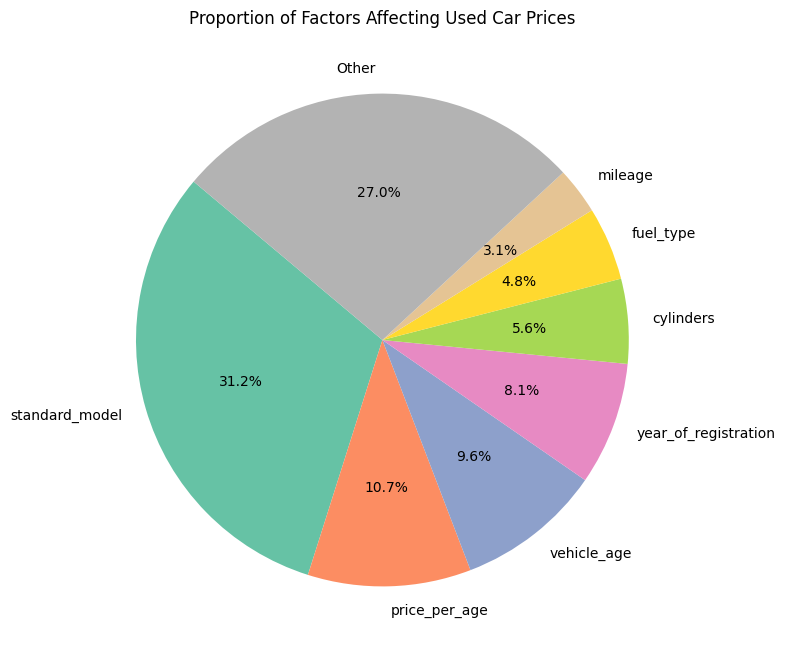

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances and feature names from your trained XGBoost
importances = xgb_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Custom mapping function to group features into meaningful categories
def map_feature_group(feat):
    if feat.startswith('make_'):
        return 'standard_make'
    elif feat.startswith('model_'):
        return 'standard_model'
    elif feat.startswith('body_type_'):
        return 'body_type'
    elif feat.startswith('color_'):
        return 'standard_colour'
    elif feat.startswith('fuel_'):
        return 'fuel_type'
    elif feat.startswith('cylinders_'):
        return 'cylinders'
    elif feat in ['odometer', 'odo_score', 'mileage_per_year']:
        return 'mileage'
    elif feat in ['vehicle_age', 'age_score']:
        return 'vehicle_age'
    elif feat == 'year':
        return 'year_of_registration'
    elif feat == 'condition_score':
        return 'condition_score'
    elif feat == 'maintenance_score':
        return 'maintenance_score'
    else:
        return feat  # leave others as is

# Apply the mapping
feat_imp_df['FeatureGroup'] = feat_imp_df['Feature'].apply(map_feature_group)

# Aggregate importances by group
agg_feat_imp = feat_imp_df.groupby('FeatureGroup')['Importance'].sum().reset_index()

# Sort descending
agg_feat_imp = agg_feat_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Select top 7 groups, lump rest into 'Other'
top_n = 7
top_features = agg_feat_imp.iloc[:top_n].copy()
other_importance = agg_feat_imp.iloc[top_n:]['Importance'].sum()
other_row = pd.DataFrame([{'FeatureGroup': 'Other', 'Importance': other_importance}])
top_features = pd.concat([top_features, other_row], ignore_index=True)

# Normalize to percentages
top_features['Importance'] = 100 * top_features['Importance'] / top_features['Importance'].sum()

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(
    top_features['Importance'],
    labels=top_features['FeatureGroup'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(top_features))
)
plt.title("Proportion of Factors Affecting Used Car Prices")
plt.show()

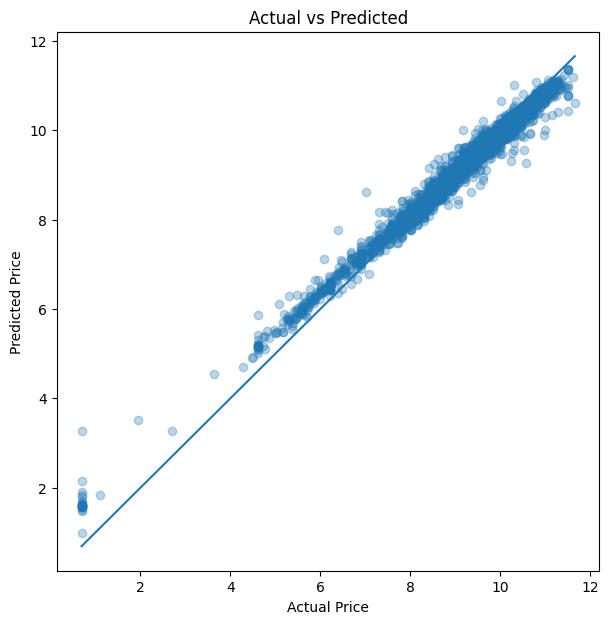

In [50]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, ensemble_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [51]:
rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))

for i in range(5):
    pred = ensemble_pred[i]
    print("Prediction:", pred)
    print("Range:", pred - rmse, "to", pred + rmse)
    print()

Prediction: 8.432951817729258
Range: 8.271525313728954 to 8.594378321729561

Prediction: 9.46818885199691
Range: 9.306762347996607 to 9.629615355997213

Prediction: 10.507483252530417
Range: 10.346056748530113 to 10.66890975653072

Prediction: 9.980165047321265
Range: 9.818738543320961 to 10.141591551321568

Prediction: 7.94140984228992
Range: 7.7799833382896155 to 8.102836346290223

